# Classificação: resolvendo problemas multiclasse

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbPipeline

## Conhecendo os dados

O conjunto de dados abrange uma ampla gama de informações, incluindo dados demográficos, socioeconômicos e macroeconômicos, dados capturados no momento da matrícula dos estudantes, bem como no final dos primeiros e segundos semestres.

As fontes de dados são diversas, incluindo fontes internas da instituição, como o Sistema de Gestão Acadêmica (AMS) e o Sistema de Apoio à Atividade Docente (PAE), bem como dados da Direção Geral do Ensino Superior (DGES) relacionados ao ingresso no ensino superior por meio do Concurso Nacional de Acesso ao Ensino Superior (CNAES). Além disso, dados macroeconômicos foram incorporados a partir da Base de Dados Portugal Contemporâneo (PORDATA).

Estes dados são representativos dos registros de estudantes matriculados no período entre os anos letivos de 2008/2009 (após a implementação do Processo de Bolonha no ensino superior europeu) e 2018/2019. Eles abrangem 17 cursos de graduação em diversas áreas do conhecimento, como agronomia, design, educação, enfermagem, jornalismo, gestão, serviço social e tecnologias.

> [Predicting Student Dropout and Academic Success](https://www.mdpi.com/2306-5729/7/11/146#app2-data-07-00146)

In [ ]:
df = pd.read_csv('https://cdn3.gnarususercontent.com.br/3068-classificacao/Projeto/Dados/dados_estudantes.csv')
df

,Estado civil,Migração,Sexo,Idade na matrícula,Estrangeiro,Necessidades educacionais especiais,Devedor,Taxas de matrícula em dia,Bolsista,Taxa de desemprego,...,disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações),Target
0,Solteiro,Sim,Masculino,20,Não,Não,Não,Sim,Não,10.8,...,0,0.000000,0,0,0,0,0,0.000000,0,Desistente
1,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,13.9,...,6,14.000000,0,0,6,6,6,13.666667,0,Graduado
2,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,10.8,...,0,0.000000,0,0,6,0,0,0.000000,0,Desistente
3,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Não,9.4,...,6,13.428571,0,0,6,10,5,12.400000,0,Graduado
4,Casado,Não,Feminino,45,Não,Não,Não,Sim,Não,13.9,...,5,12.333333,0,0,6,6,6,13.000000,0,Graduado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,Solteiro,Não,Masculino,19,Não,Não,Não,Sim,Não,15.5,...,5,13.600000,0,0,6,8,5,12.666667,0,Graduado
4420,Solteiro,Sim,Feminino,18,Sim,Não,Sim,Não,Não,11.1,...,6,12.000000,0,0,6,6,2,11.000000,0,Desistente
4421,Solteiro,Sim,Feminino,30,Não,Não,Não,Sim,Sim,13.9,...,7,14.912500,0,0,8,9,1,13.500000,0,Desistente
4422,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Sim,9.4,...,5,13.800000,0,0,5,6,5,12.000000,0,Graduado


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Estado civil                              4424 non-null   object 
 1   Migração                                  4424 non-null   object 
 2   Sexo                                      4424 non-null   object 
 3   Idade na matrícula                        4424 non-null   int64  
 4   Estrangeiro                               4424 non-null   object 
 5   Necessidades educacionais especiais       4424 non-null   object 
 6   Devedor                                   4424 non-null   object 
 7   Taxas de matrícula em dia                 4424 non-null   object 
 8   Bolsista                                  4424 non-null   object 
 9   Taxa de desemprego                        4424 non-null   float64
 10  Taxa de inflação                    

In [ ]:
df['Target'].unique()

array(['Desistente', 'Graduado', 'Matriculado'], dtype=object)

In [ ]:
df.describe()

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações)
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,23.265145,11.566139,1.228029,0.001969,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316
std,7.587816,2.663850,1.382711,2.269935,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774
min,17.000000,7.600000,-0.800000,-4.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,9.400000,0.300000,-1.700000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000
50%,20.000000,11.100000,1.400000,0.320000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000
75%,25.000000,13.900000,2.600000,1.790000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000
max,70.000000,16.200000,3.700000,3.510000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000


In [ ]:
df.describe(include='object')

,Estado civil,Migração,Sexo,Estrangeiro,Necessidades educacionais especiais,Devedor,Taxas de matrícula em dia,Bolsista,Curso,Período,Qualificação prévia,Target
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,2,2,2,2,2,2,2,17,2,17,3
top,Solteiro,Sim,Feminino,Não,Não,Não,Sim,Não,Enfermagem,Diurno,Educação secundária,Graduado
freq,3919,2426,2868,4314,4373,3921,3896,3325,766,3941,3717,2209


## Explorando os dados

### Dados demográficos

In [ ]:
df['Estado civil'].value_counts(normalize=True) * 100

,proportion
Estado civil,
Solteiro,88.584991
Casado,8.566908
Divorciado,2.056962
União Estável,0.565099
Legalmente Separado,0.135624
Viúvo,0.090416


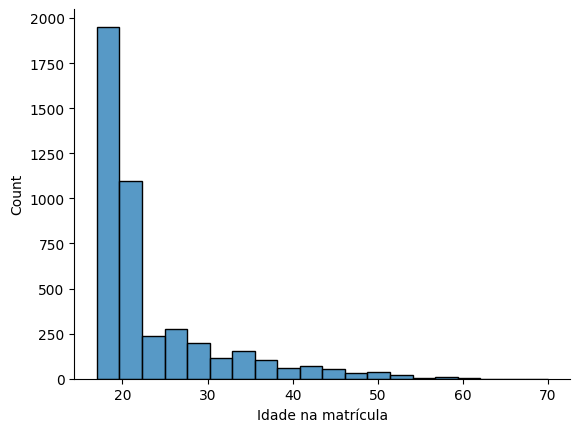

In [ ]:
sns.histplot(df['Idade na matrícula'], bins=20)
sns.despine()
plt.show()

In [ ]:
color_dict = {'Desistente': '#e34c42', 'Graduado': '#4dc471', 'Matriculado': '#3b71db'}
sns.set_palette(list(color_dict.values()))

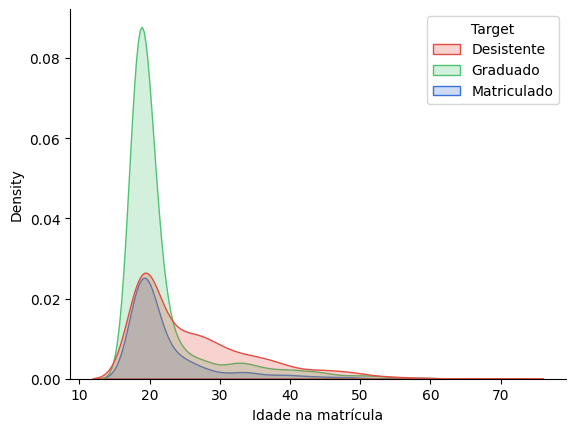

In [ ]:
sns.kdeplot(df, x='Idade na matrícula', hue='Target', fill=True)
sns.despine()
plt.show()

In [ ]:
df['Estrangeiro'].value_counts(normalize=True) * 100

,proportion
Estrangeiro,
Não,97.513562
Sim,2.486438


In [ ]:
df['Sexo'].value_counts(normalize=True) * 100

,proportion
Sexo,
Feminino,64.82821
Masculino,35.17179


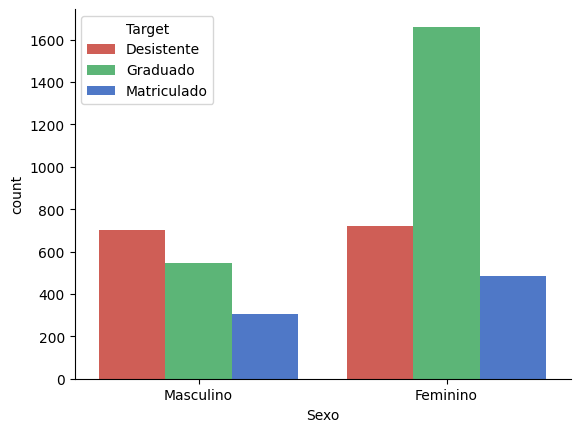

In [ ]:
sns.countplot(df, x='Sexo', hue='Target')
sns.despine()
plt.show()

### Dados socioeconômicos e macroeconômicos

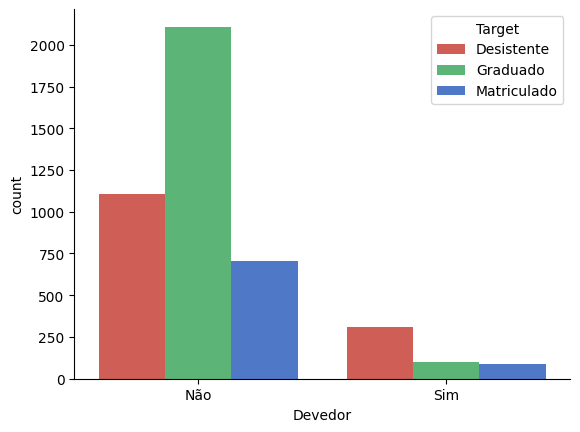

In [ ]:
sns.countplot(df, x='Devedor', hue='Target')
sns.despine()
plt.show()

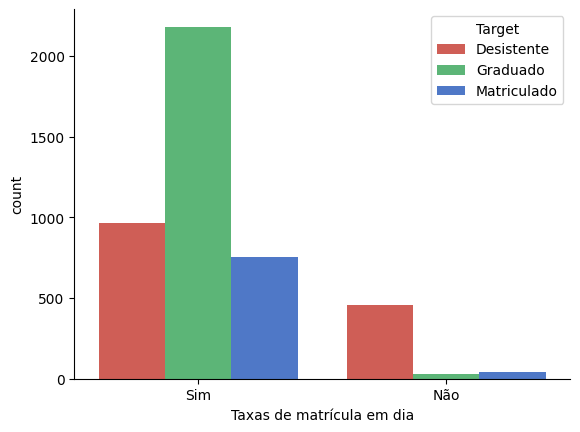

In [ ]:
sns.countplot(df, x='Taxas de matrícula em dia', hue='Target')
sns.despine()
plt.show()

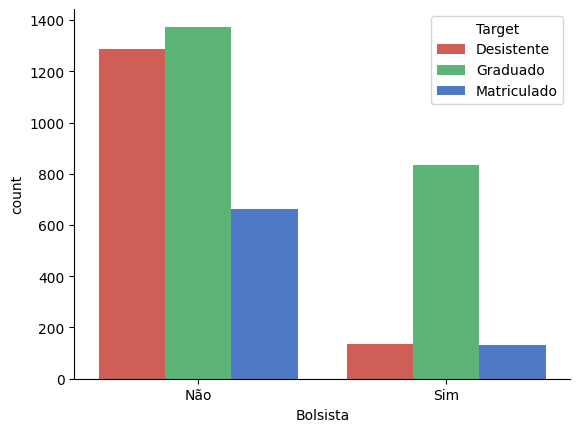

In [ ]:
sns.countplot(df, x='Bolsista', hue='Target')
sns.despine()
plt.show()

### Dados dos cursos

In [ ]:
contagem = df.groupby(['Curso', 'Target']).size().reset_index(name='Contagem')

contagem['Porcentagem'] = contagem.groupby('Curso')['Contagem'].transform(lambda x: (x / x.sum()) * 100)

fig = px.bar(contagem, y='Curso', x='Porcentagem', color='Target', orientation='h',
             color_discrete_map=color_dict)
fig.show()

### Dados acadêmicos

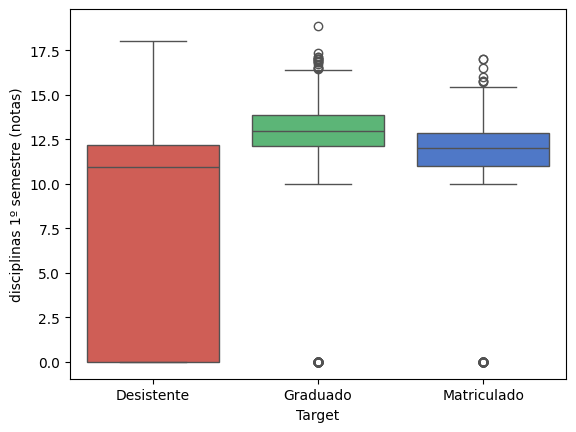

In [ ]:
sns.boxplot(df, x='Target', y='disciplinas 1º semestre (notas)', hue='Target');

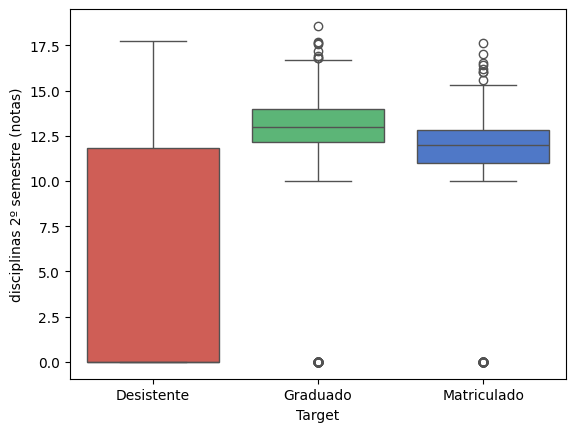

In [ ]:
sns.boxplot(df, x='Target', y='disciplinas 2º semestre (notas)', hue='Target');

In [ ]:
df['Target'].value_counts(normalize=True) * 100

,proportion
Target,
Graduado,49.932188
Desistente,32.120253
Matriculado,17.947559


### Outras análises

- Migração

In [ ]:
df['Migração'].value_counts(normalize=True) * 100

,proportion
Migração,
Sim,54.837251
Não,45.162749


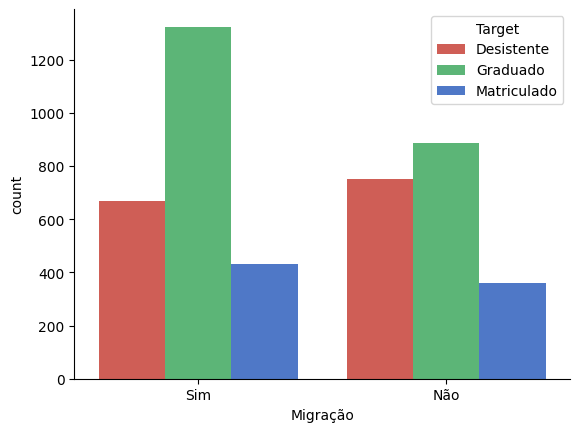

In [ ]:
sns.countplot(df, x='Migração', hue='Target');
sns.despine()

- Necessidades educacionais especiais

In [ ]:
df['Necessidades educacionais especiais'].value_counts(normalize=True) * 100

,proportion
Necessidades educacionais especiais,
Não,98.847197
Sim,1.152803


In [ ]:
df.groupby('Target')['Necessidades educacionais especiais'].value_counts(normalize=True) * 100

Target       Necessidades educacionais especiais
Desistente   Não                                    98.803659
             Sim                                     1.196341
Graduado     Não                                    98.958805
             Sim                                     1.041195
Matriculado  Não                                    98.614610
             Sim                                     1.385390
Name: proportion, dtype: float64

- Taxa de desemprego

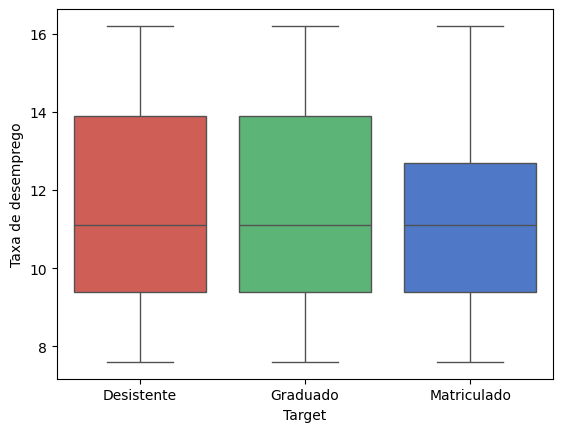

In [ ]:
sns.boxplot(df, x='Target', y='Taxa de desemprego', hue='Target');

- Taxa de inflação

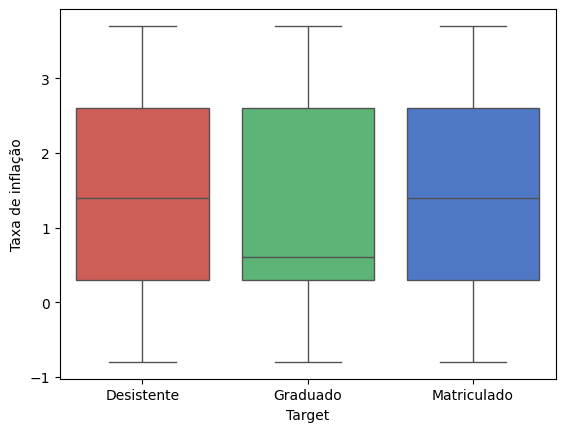

In [ ]:
sns.boxplot(df, x='Target', y='Taxa de inflação', hue='Target');

- PIB

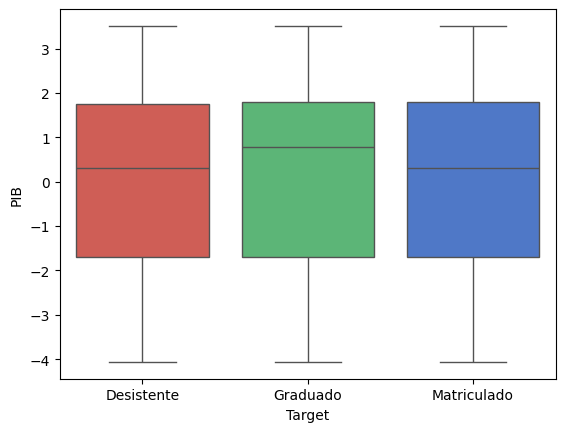

In [ ]:
sns.boxplot(df, x='Target', y='PIB', hue='Target');

- Qualificação prévia

In [ ]:
df['Qualificação prévia'].value_counts(normalize=True) * 100

,proportion
Qualificação prévia,
Educação secundária,84.018987
Curso de especialização tecnológica,4.950271
Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente,3.661844
Educação superior - licenciatura,2.848101
Outro - 11º ano de escolaridade,1.017179
Educação superior - licenciatura (1º ciclo),0.904159
Curso técnico superior profissional,0.813743
Educação superior - bacharelado,0.519892
Frequência de educação superior,0.361664


## Realizando o treinamento

In [ ]:
colunas_categoricas = ['Migração', 'Sexo','Estrangeiro', 'Necessidades educacionais especiais', 'Devedor',
                     'Taxas de matrícula em dia', 'Bolsista', 'Período','Estado civil', 'Curso', 'Qualificação prévia']

In [ ]:
encoder = OneHotEncoder(drop='if_binary')

df_categorico = df[colunas_categoricas]

df_encoded = pd.DataFrame(encoder.fit_transform(df_categorico).toarray(),
                          columns=encoder.get_feature_names_out(colunas_categoricas))

df_final = pd.concat([df.drop(colunas_categoricas, axis=1),
                      df_encoded], axis=1)

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),...,Qualificação prévia_Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente,Qualificação prévia_Educação secundária,Qualificação prévia_Educação superior - bacharelado,Qualificação prévia_Educação superior - doutorado,Qualificação prévia_Educação superior - licenciatura,Qualificação prévia_Educação superior - licenciatura (1º ciclo),Qualificação prévia_Educação superior - mestrado,Qualificação prévia_Educação superior - mestrado (2º ciclo),Qualificação prévia_Frequência de educação superior,Qualificação prévia_Outro - 11º ano de escolaridade
0,20,10.8,1.4,1.74,0,0,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,19,13.9,-0.3,0.79,0,6,6,6,14.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19,10.8,1.4,1.74,0,6,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20,9.4,-0.8,-3.12,0,6,8,6,13.428571,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,45,13.9,-0.3,0.79,0,6,9,5,12.333333,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,19,15.5,2.8,-4.06,0,6,7,5,13.600000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4420,18,11.1,0.6,2.02,0,6,6,6,12.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4421,30,13.9,-0.3,0.79,0,7,8,7,14.912500,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4422,20,9.4,-0.8,-3.12,0,5,5,5,13.800000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X = df_final.drop(columns='Target')
y = df_final['Target']

In [ ]:
X, X_test, y, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=0)
X_treino, X_val, y_treino, y_val = train_test_split(X, y, stratify=y, random_state=0)

In [ ]:
modelo_rf = RandomForestClassifier(random_state=0)
modelo_rf.fit(X_treino, y_treino)

y_pred = modelo_rf.predict(X_val)

print(f"Acurácia de treino: {modelo_rf.score(X_treino, y_treino)}")
print(f"Acurácia de validação: {modelo_rf.score(X_val, y_val)}")

Acurácia de treino: 0.9975177304964539
Acurácia de validação: 0.7680851063829788


In [ ]:
modelo_rf = RandomForestClassifier(max_depth=10, random_state=0)
modelo_rf.fit(X_treino, y_treino)

y_pred = modelo_rf.predict(X_val)

print(f"Acurácia de treino: {modelo_rf.score(X_treino, y_treino)}")
print(f"Acurácia de validação: {modelo_rf.score(X_val, y_val)}")

Acurácia de treino: 0.898936170212766
Acurácia de validação: 0.7734042553191489


### Desafio: utilizando outro classificador

In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier(max_depth=10, random_state=0)
modelo_dt.fit(X_treino, y_treino)

y_pred_dt = modelo_dt.predict(X_val)

print(f"Acurácia de treino: {modelo_dt.score(X_treino, y_treino)}")
print(f"Acurácia de validação: {modelo_dt.score(X_val, y_val)}")

Acurácia de treino: 0.8776595744680851
Acurácia de validação: 0.7457446808510638


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

modelo_gb = GradientBoostingClassifier(random_state=0)
modelo_gb.fit(X_treino, y_treino)

y_pred_gb = modelo_gb.predict(X_val)

print(f"Acurácia de treino: {modelo_gb.score(X_treino, y_treino)}")
print(f"Acurácia de validação: {modelo_gb.score(X_val, y_val)}")

Acurácia de treino: 0.8411347517730496
Acurácia de validação: 0.7691489361702127


## Avaliando o modelo

### Analisando a matriz de confusão

In [ ]:
matriz_confusao = confusion_matrix(y_val, y_pred)

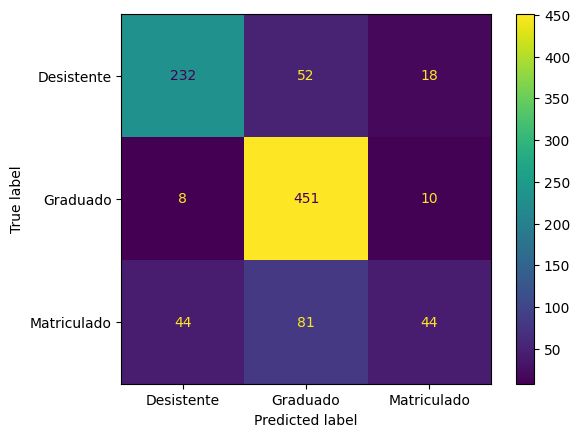

In [ ]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=modelo_rf.classes_)
visualizacao.plot();

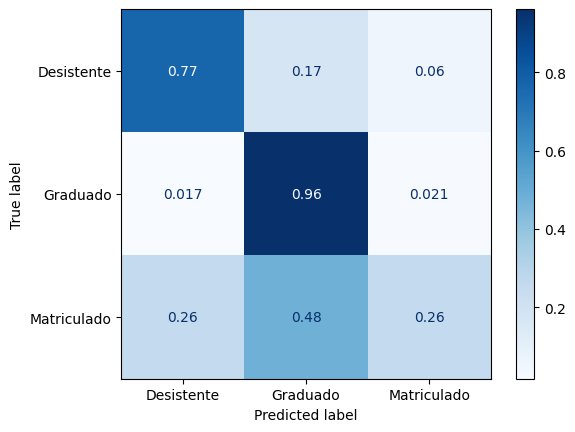

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues');

### Analisando o relatório de métricas

In [ ]:
report = classification_report(y_val, y_pred)

print("Relatório de Classificação:\n", report)

Relatório de Classificação:
               precision    recall  f1-score   support

  Desistente       0.82      0.77      0.79       302
    Graduado       0.77      0.96      0.86       469
 Matriculado       0.61      0.26      0.37       169

    accuracy                           0.77       940
   macro avg       0.73      0.66      0.67       940
weighted avg       0.76      0.77      0.75       940



## Aplicando técnica de superamostragem

In [ ]:
y_treino.value_counts()

,count
Target,
Graduado,1408
Desistente,906
Matriculado,506


In [ ]:
oversample = SMOTE(random_state=0)
X_balanceado, y_balanceado = oversample.fit_resample(X_treino, y_treino)

In [ ]:
y_balanceado.value_counts()

,count
Target,
Desistente,1408
Graduado,1408
Matriculado,1408


In [ ]:
modelo = RandomForestClassifier(max_depth=10, random_state=0)
modelo.fit(X_balanceado, y_balanceado)
y_pred = modelo.predict(X_val)

## Analisando as métricas após o balanceamento

              precision    recall  f1-score   support

  Desistente       0.85      0.72      0.78       302
    Graduado       0.81      0.87      0.84       469
 Matriculado       0.48      0.52      0.50       169

    accuracy                           0.76       940
   macro avg       0.72      0.70      0.71       940
weighted avg       0.77      0.76      0.76       940



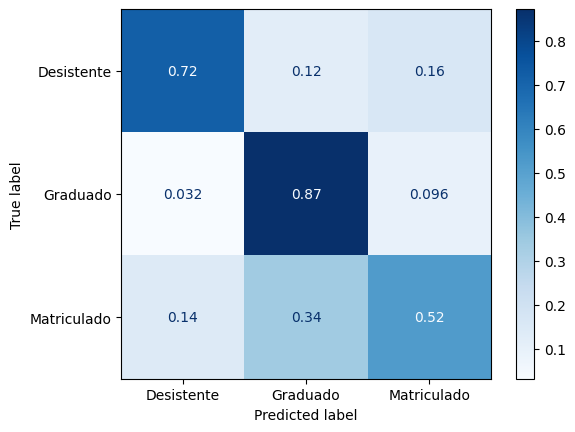

In [ ]:
print(classification_report(y_val, y_pred))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues');

### Desafio: analisando as métricas com o outro classificador

              precision    recall  f1-score   support

  Desistente       0.76      0.63      0.69       302
    Graduado       0.80      0.84      0.82       469
 Matriculado       0.36      0.43      0.40       169

    accuracy                           0.70       940
   macro avg       0.64      0.63      0.63       940
weighted avg       0.71      0.70      0.70       940



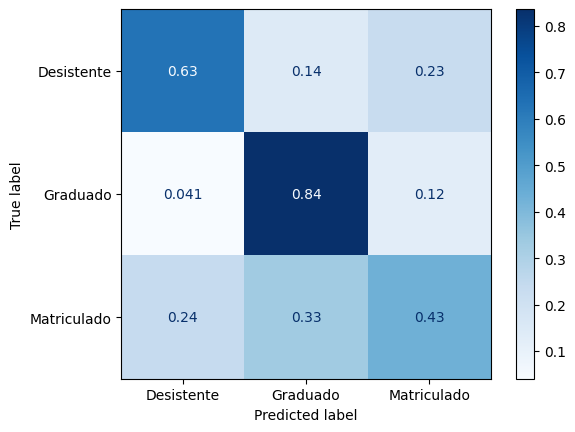

In [ ]:
modelo_dt = DecisionTreeClassifier(max_depth=10, random_state=0)
modelo_dt.fit(X_balanceado, y_balanceado)
y_pred_dt = modelo_dt.predict(X_val)

print(classification_report(y_val, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_dt, normalize='true', cmap='Blues');

              precision    recall  f1-score   support

  Desistente       0.82      0.73      0.78       302
    Graduado       0.82      0.89      0.85       469
 Matriculado       0.50      0.47      0.48       169

    accuracy                           0.76       940
   macro avg       0.71      0.70      0.70       940
weighted avg       0.76      0.76      0.76       940



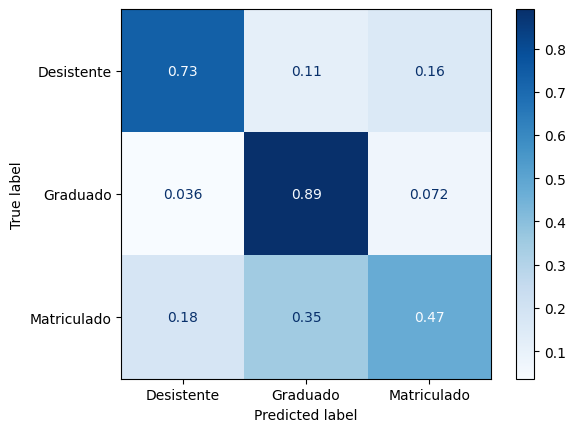

In [ ]:
modelo_gb = GradientBoostingClassifier(random_state=0)
modelo_gb.fit(X_balanceado, y_balanceado)
y_pred_gb = modelo_gb.predict(X_val)

print(classification_report(y_val, y_pred_gb))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_gb, normalize='true', cmap='Blues');

## Validando o modelo

In [ ]:
modelo = RandomForestClassifier(max_depth=10, random_state=0)

pipeline = imbPipeline([('oversample', SMOTE(random_state=0)), ('floresta', modelo)])

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

cv_results = cross_validate(pipeline, X, y, cv=skf, scoring='recall_weighted')
cv_results['test_score']

array([0.77925532, 0.7393617 , 0.75132979, 0.77393617, 0.75132979])

In [ ]:
media = cv_results['test_score'].mean()
desvio_padrao = cv_results['test_score'].std()

print(f"Intervalo de Confiança: [{media - 2 * desvio_padrao}, {min(media + 2 * desvio_padrao, 1)}]")

Intervalo de Confiança: [0.7288871536530673, 0.7891979527299114]


### Testando o modelo

              precision    recall  f1-score   support

  Desistente       0.88      0.75      0.81       213
    Graduado       0.82      0.85      0.84       332
 Matriculado       0.50      0.59      0.54       119

    accuracy                           0.77       664
   macro avg       0.73      0.73      0.73       664
weighted avg       0.78      0.77      0.77       664



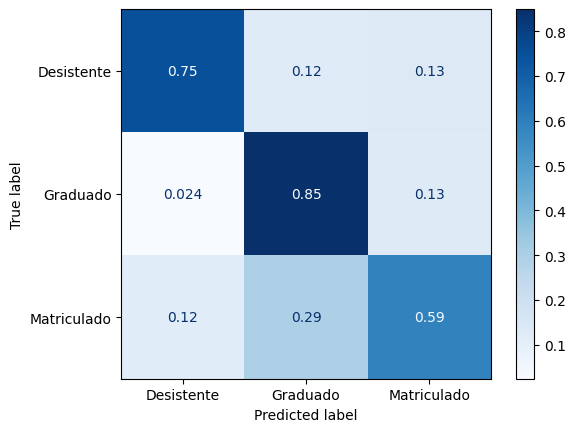

In [ ]:
oversample = SMOTE(random_state=0)
X_balanceado, y_balanceado = oversample.fit_resample(X, y)

modelo = RandomForestClassifier(max_depth=10, random_state=0)
modelo.fit(X_balanceado, y_balanceado)
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', cmap='Blues');

## Desafio final

O desafio final consiste em utilizar um conjunto de dados, proveniente do [Kaggle](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset), que contém informações detalhadas sobre várias características químicas de vinhos produzidos por uma vinícola. O dataset original teve as colunas traduzidas para português e os vinhos foram classificados em três categorias: Ruim, Mediano e Bom.

Agora, sua tarefa é construir um modelo de classificação multiclasse capaz de prever a qualidade dos vinhos com base nessas características químicas. Isso ajudará a equipe da vinícola a identificar rapidamente os vinhos que precisam de ajustes na produção ou que podem ser destacados como excepcionais.

Para construir este modelo, você precisará realizar as seguintes etapas:

1. Ler a URL utilizando a biblioteca pandas e armazenar os dados em uma variável.
2. Visualizar o DataFrame para verificar a presença de dados nulos e determinar se é necessário realizar algum pré-processamento.
3. Separar as features em uma variável X e a coluna-alvo em uma variável y.
4. Dividir os dados em conjuntos de treinamento, validação e teste.
5. Treinar o algoritmo de classificação Random Forest utilizando os dados de treinamento.
6. Avaliar o desempenho do modelo por meio da matriz de confusão e de um relatório de métricas.
7. Avaliar a necessidade de balanceamento dos dados. Caso seja necessário, realizar o balanceamento e treinar o modelo novamente.
8. Realizar validação cruzada para garantir a robustez do modelo.
9. Testar o modelo com dados de teste que nunca foram previamente observados pelo modelo.

In [ ]:
df_desafio = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/classificacao_multiclasse/main/Dados/df_vinho.csv')
df_desafio

,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool,qualidade
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,mediano
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,mediano
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,mediano
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,mediano
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,mediano
...,...,...,...,...,...,...,...,...,...,...,...,...
1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,mediano
1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,mediano
1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,mediano
1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,mediano


- Explorando os dados

In [ ]:
df_desafio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   acidez fixa                1359 non-null   float64
 1   acidez volátil             1359 non-null   float64
 2   ácido cítrico              1359 non-null   float64
 3   açúcar residual            1359 non-null   float64
 4   cloretos                   1359 non-null   float64
 5   dióxido de enxofre livre   1359 non-null   float64
 6   dióxido de enxofre total   1359 non-null   float64
 7   densidade                  1359 non-null   float64
 8   pH                         1359 non-null   float64
 9   sulfatos                   1359 non-null   float64
 10  álcool                     1359 non-null   float64
 11  qualidade                  1359 non-null   object 
dtypes: float64(11), object(1)
memory usage: 127.5+ KB


In [ ]:
df_desafio.describe()

,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [ ]:
df_desafio['qualidade'].unique()

array(['mediano', 'bom', 'ruim'], dtype=object)

In [ ]:
df_desafio['qualidade'].value_counts(normalize=True) * 100

,proportion
qualidade,
mediano,81.824871
bom,13.539367
ruim,4.635762


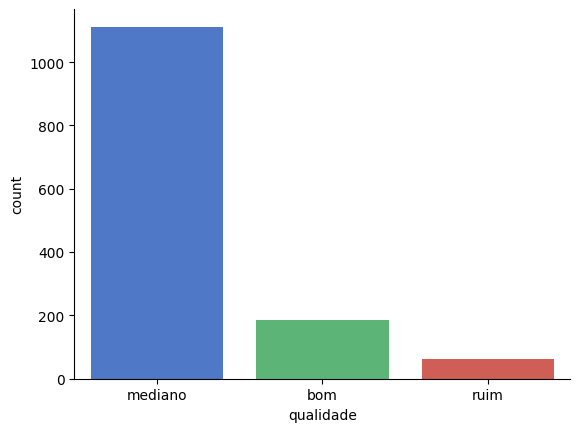

In [ ]:
color_dict = {'ruim': '#e34c42', 'bom': '#4dc471', 'mediano': '#3b71db'}

sns.countplot(df_desafio, x='qualidade', hue='qualidade', palette=color_dict)
sns.despine()

- Separando os dados

In [ ]:
X = df_desafio.drop(columns='qualidade')
y = df_desafio['qualidade']

In [ ]:
X_desafio, X_test, y_desafio, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=0)
X_treino_desafio, X_val_desafio, y_treino_desafio, y_val_desafio = train_test_split(X_desafio, y_desafio, stratify=y_desafio, random_state=0)

- Avaliação inicial do modelo

In [ ]:
modelo_desafio = RandomForestClassifier(max_depth=8, random_state=0)
modelo_desafio.fit(X_treino_desafio, y_treino_desafio)

y_pred_desafio = modelo_desafio.predict(X_val_desafio)

print(f"Acurácia de treino: {modelo_desafio.score(X_treino_desafio, y_treino_desafio)}")
print(f"Acurácia de validação: {modelo_desafio.score(X_val_desafio, y_val_desafio)}")

Acurácia de treino: 0.9422632794457275
Acurácia de validação: 0.8408304498269896


              precision    recall  f1-score   support

         bom       0.71      0.31      0.43        39
     mediano       0.85      0.98      0.91       236
        ruim       0.00      0.00      0.00        14

    accuracy                           0.84       289
   macro avg       0.52      0.43      0.45       289
weighted avg       0.79      0.84      0.80       289



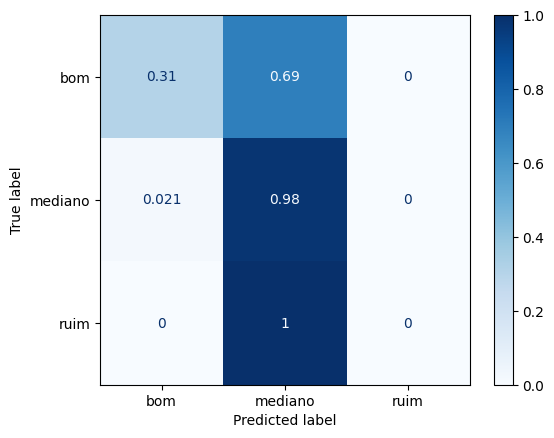

In [ ]:
print(classification_report(y_val_desafio, y_pred_desafio, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_val_desafio, y_pred_desafio, normalize='true', cmap='Blues');

- Balanceando os dados

              precision    recall  f1-score   support

         bom       0.40      0.72      0.51        39
     mediano       0.92      0.72      0.80       236
        ruim       0.23      0.57      0.33        14

    accuracy                           0.71       289
   macro avg       0.52      0.67      0.55       289
weighted avg       0.82      0.71      0.74       289



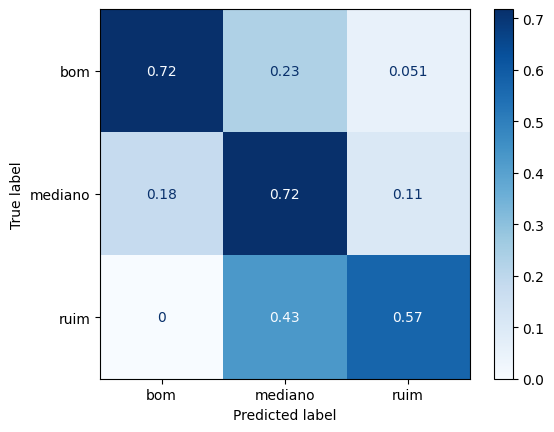

In [ ]:
oversample_desafio = SMOTE(random_state=0)
X_balanceado_desafio, y_balanceado_desafio = oversample_desafio.fit_resample(X_treino_desafio, y_treino_desafio)

modelo_desafio = RandomForestClassifier(max_depth=8, random_state=0)
modelo_desafio.fit(X_balanceado_desafio, y_balanceado_desafio)
y_pred_desafio = modelo_desafio.predict(X_val_desafio)

print(classification_report(y_val_desafio, y_pred_desafio))
ConfusionMatrixDisplay.from_predictions(y_val_desafio, y_pred_desafio, normalize='true', cmap='Blues');

- Validaçãa cruzada

In [ ]:
pipeline = imbPipeline([('oversample', SMOTE(random_state=0)), ('floresta', modelo_desafio)])

skf_desafio = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

cv_results_desafio = cross_validate(pipeline, X_desafio, y_desafio, cv=skf_desafio, scoring='recall_weighted')
cv_results_desafio['test_score']

array([0.74025974, 0.74891775, 0.67532468, 0.74891775, 0.74458874])

In [ ]:
media_desafio = cv_results_desafio['test_score'].mean()
desvio_padrao_desafio = cv_results_desafio['test_score'].std()

print(f"Intervalo de Confiança: {media_desafio} -> [{media_desafio - 2 * desvio_padrao_desafio}, {min(media_desafio + 2 * desvio_padrao_desafio, 1)}]")

Intervalo de Confiança: 0.7316017316017316 -> [0.6749595593634766, 0.7882439038399865]


- Testando modelo final

              precision    recall  f1-score   support

         bom       0.44      0.61      0.51        28
     mediano       0.90      0.79      0.84       167
        ruim       0.32      0.67      0.43         9

    accuracy                           0.76       204
   macro avg       0.55      0.69      0.59       204
weighted avg       0.81      0.76      0.78       204



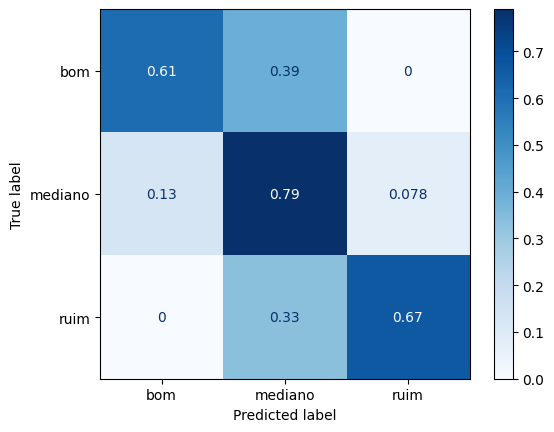

In [ ]:
oversample_desafio = SMOTE(random_state=0)
X_balanceado_desafio, y_balanceado_desafio = oversample_desafio.fit_resample(X_desafio, y_desafio)

modelo_desafio = RandomForestClassifier(max_depth=8, random_state=0)
modelo_desafio.fit(X_balanceado_desafio, y_balanceado_desafio)
y_pred_desafio = modelo_desafio.predict(X_test)

print(classification_report(y_test, y_pred_desafio))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_desafio, normalize='true', cmap='Blues');